# Transmon-controlled beamsplitter between two cavities, from two detuned sidebands

**Q1** (transmon, Duffing) — **C1**, **C2** (linear cavities). Tensor order
**C1 $\otimes$ C2 $\otimes$ Q1**. Rates are angular frequencies in rad/µs, so `/2pi`
reads out in MHz; times are µs. Every pulse is run through `qutip.mesolve` with
Gaussian rise/fall — no square pulses anywhere.

### The scheme

Both pumps sit on the $|e,1\rangle-|f,0\rangle$ sideband, cavity 1 at detuning $d_1$
and cavity 2 at $d_2$. Since there is no $\chi$, $|e,n\rangle-|f,n{-}1\rangle$ is
resonant for every $n$, so the mechanism is photon-number independent by construction —
which is the whole point, and why everything below is scored up to $N$ photons rather
than in the single-photon dual-rail sector.

### What each task does

| task | question |
|---|---|
| **1** | Sweep $d_2$ and time, plot the chevron with Q1 in $g$ / $e$, for initial Fock states $\vert n,0\rangle$, $n=1\dots N$. Does the conditional swap happen, and at the same detuning for every $n$? |
| **2** | The conditional beamsplitter gate: optimal virtual-Z gates, random-state fidelity **vs photon number**, and a Hinton comparison against the ideal gate for a state you choose |
| **3** | The dynamical $\chi$ (the conditional photon-number / parity phase): can a two-tone echo — first half near $e1f0$, second half near $g1e0$, $\pi$ pulse between — null it? |

### Notation

$\alpha$ anharmonicity; $g_j$, $d_j$ the activated sideband rate and detuning of pump $j$;
$\Delta\phi=\phi_2-\phi_1$ the relative pump phase (it sets the beamsplitter axis);
$\sigma$ the Gaussian pump edge ($2\sigma$ long at each end of every section).

## Functions 1 — operators, Hamiltonian, pulses, evolution

The frame: start from
$H_A(t)=\frac{\alpha}{2}n_q(n_q-1)+\sum_jg_j(e^{i(\theta_jt+\phi_j)}a_jq^\dagger+\mathrm{h.c.})$,
with $\theta_j=-\alpha+d_j$ for pumps parked on the **ef** sideband and $\theta_j=d_j$ for
the **ge** sideband. Each coupling term holds exactly one cavity operator, so rotating
cavity $j$ by $\theta_j$ makes everything static for *any* $d_1,d_2$:

$$H=-\theta_1n_1-\theta_2n_2+\frac{\alpha}{2}n_q(n_q-1) +\sum_j\chi_jn_jn_q+\sum_j\frac{K_j}{2}n_j(n_j-1) +\sum_jg_j\left(e^{i\phi_j}a_jq^\dagger+\mathrm{h.c.}\right)$$

$n_1+n_2+n_q$ is conserved (these are conversion terms), so the only two-cavity process
available is exchange — never two-mode squeezing, at any order.

In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.optimize import minimize
from scipy.special import erf

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "legend.fontsize": 8, "axes.titlesize": 10})
TWOPI = 2 * np.pi
MHz = TWOPI                      # 30 * MHz is an angular frequency in rad/us
SOLVER = dict(atol=1e-11, rtol=1e-9, nsteps=10 ** 7, progress_bar=False)

# ---------------------------------------------------------------- parameters
DEFAULTS = dict(
    Nc=10, Nq=4,                  # cavity / transmon truncation
    alpha=-150 * MHz,            # transmon anharmonicity
    park="ef",                   # "ef": pumps on |e,1>-|f,0>;  "ge": on |g,1>-|e,0>
    g1=1 * MHz, g2=1 * MHz,      # activated sideband rates
    d1=15 * MHz, d2=15 * MHz,    # sideband detunings
    phi1=0.0, phi2=0.0,          # pump phases (only phi2 - phi1 is physical)
    sigma=0.020,                 # Gaussian pump edge, 2*sigma at each end
    chi1=0.0, chi2=0.0,          # residual cavity-transmon dispersive shift
    kerr1=0.0, kerr2=0.0,        # cavity self-Kerr
    kappa1=0.0, kappa2=0.0,      # cavity decay
    gamma=0.0, gamma_phi=0.0,    # transmon decay / dephasing
)


def par(**kw):
    "DEFAULTS updated with kw; unknown keys are rejected so typos cannot pass silently."
    bad = set(kw) - set(DEFAULTS)
    if bad:
        raise KeyError(f"unknown parameter(s): {sorted(bad)}")
    return {**DEFAULTS, **kw}


# ---------------------------------------------------------------- operators
_CACHE = {}


def ops_for(p):
    "Operator namespace for this truncation (cached; C1 (x) C2 (x) Q1)."
    key = (p["Nc"], p["Nq"])
    if key in _CACHE:
        return _CACHE[key]
    Nc, Nq = key
    Ic, Iq = qt.qeye(Nc), qt.qeye(Nq)
    a1 = qt.tensor(qt.destroy(Nc), Ic, Iq)
    a2 = qt.tensor(Ic, qt.destroy(Nc), Iq)
    q = qt.tensor(Ic, Ic, qt.destroy(Nq))
    o = dict(Nc=Nc, Nq=Nq, dim=Nc * Nc * Nq, a1=a1, a2=a2, q=q,
             n1=a1.dag() * a1, n2=a2.dag() * a2, nq=q.dag() * q,
             P=[qt.tensor(Ic, Ic, qt.basis(Nq, k) * qt.basis(Nq, k).dag())
                for k in range(Nq)])
    o["N"] = o["n1"] + o["n2"]
    o["Ntot"] = o["N"] + o["nq"]
    _CACHE[key] = o
    return o


def ket(o, n1, n2, k):
    "|n1, n2, k>"
    return qt.tensor(qt.basis(o["Nc"], n1), qt.basis(o["Nc"], n2),
                     qt.basis(o["Nq"], k))


def flat_index(o, n1, n2, k):
    "position of |n1, n2, k> in the flattened basis"
    return (n1 * o["Nc"] + n2) * o["Nq"] + k


# ---------------------------------------------------------------- Hamiltonian
def hamiltonian(p, drive=True, phi2_offset=0.0, phi_common=0.0):
    '''
    The static Hamiltonian above.  drive=False keeps only what the ramps multiply.
    phi2_offset shifts pump 2 alone (the echo's relative-phase flip); phi_common shifts
    BOTH pumps, which is the junction phase needed when the pump frequency changes
    between sections -- see task 3.
    '''
    o = ops_for(p)
    off = -p["alpha"] if p["park"] == "ef" else 0.0
    th1, th2 = off + p["d1"], off + p["d2"]

    H = (-th1 * o["n1"] - th2 * o["n2"]
         + 0.5 * p["alpha"] * o["nq"] * (o["nq"] - 1)
         + p["chi1"] * o["n1"] * o["nq"] + p["chi2"] * o["n2"] * o["nq"]
         + 0.5 * p["kerr1"] * o["n1"] * (o["n1"] - 1)
         + 0.5 * p["kerr2"] * o["n2"] * (o["n2"] - 1))
    if not drive:
        return H
    ex1 = np.exp(1j * (p["phi1"] + phi_common)) * o["a1"] * o["q"].dag()
    ex2 = np.exp(1j * (p["phi2"] + phi2_offset + phi_common)) * o["a2"] * o["q"].dag()
    return H + p["g1"] * (ex1 + ex1.dag()) + p["g2"] * (ex2 + ex2.dag())


def c_ops_for(p):
    "Lindblad operators.  Frame-invariant, since D[e^{i phi} a] = D[a]."
    o = ops_for(p)
    out = []
    for rate, A in ((p["kappa1"], o["a1"]), (p["kappa2"], o["a2"]),
                    (p["gamma"], o["q"])):
        if rate > 0:
            out.append(np.sqrt(rate) * A)
    if p["gamma_phi"] > 0:
        out.append(np.sqrt(2 * p["gamma_phi"]) * o["nq"])
    return out


# ---------------------------------------------------------------- pulses
RISE = "exp(-((t - tr)**2) / (2 * sig**2))"      # t is local to each step
FALL = "exp(-(t**2) / (2 * sig**2))"


def section(p, T, phi2_offset=0.0, phi_common=0.0):
    '''
    One drive section of total duration T: Gaussian rise (2 sigma), flat top, Gaussian
    fall (2 sigma).  Returned as a list of steps for run_steps().
    '''
    s = p["sigma"]
    flat = T - 4 * s
    if flat < 0:
        raise ValueError(f"section T={T:.4g} us is shorter than 4*sigma={4*s:.4g} us")
    Hd = hamiltonian(p, drive=False)
    Hf = hamiltonian(p, phi2_offset=phi2_offset, phi_common=phi_common)
    args = dict(tr=2 * s, sig=s)
    return [("Ht", [Hd, [Hf - Hd, RISE]], 2 * s, args),
            ("H", Hf, flat),
            ("Ht", [Hd, [Hf - Hd, FALL]], 2 * s, args)]


def pi_pulse(p, phase=0.0):
    "Instantaneous ge pi pulse; identity on k >= 2."
    o = ops_for(p)
    g, e = qt.basis(o["Nq"], 0), qt.basis(o["Nq"], 1)
    X = (-1j * np.exp(1j * phase) * g * e.dag() - 1j * np.exp(-1j * phase) * e * g.dag()
         + qt.qeye(o["Nq"]) - g * g.dag() - e * e.dag())
    return qt.tensor(qt.qeye(o["Nc"]), qt.qeye(o["Nc"]), X)


def ramp_area(T, sigma, n_sections=1):
    '''
    Square-pulse duration with the same pulse *area in g^2*, which is what sets the
    gate angle.  Each Gaussian edge contributes sigma*sqrt(pi)/2*erf(2) = 0.882 sigma
    of the 2 sigma it occupies.
    '''
    if sigma <= 0:
        return T
    return T - n_sections * 2 * (2 * sigma - sigma * np.sqrt(np.pi) / 2 * erf(2.0))


# ---------------------------------------------------------------- evolution
def run_steps(steps, state, c_ops=()):
    '''
    Run a step list through mesolve.  Steps are
        ("H",  H, duration)                 static
        ("Ht", H_list, duration, args)      time dependent, t local to the step
        ("U",  U)                           instantaneous unitary
    A ket stays a ket while nothing dissipates; operators are conjugated properly.
    '''
    for st in steps:
        if st[0] == "U":
            state = st[1] * state * st[1].dag() if state.isoper else st[1] * state
            continue
        H, T = st[1], st[2]
        if T <= 0:
            continue
        args = st[3] if st[0] == "Ht" else None
        state = qt.mesolve(H, state, [0.0, T], list(c_ops), e_ops=[], args=args,
                           options=SOLVER).states[-1]
    return state

## Functions 2 — the gate sequence, the ideal target, virtual Z, fidelity

**The gate.** $T/2$ of pumps, a ge $\pi$ pulse, $T/2$ more with **one** pump's phase
flipped by $180^\circ$, then a closing $\pi$ pulse. Flipping the relative phase sends
$J\to-J$ while $\chi\propto g_j^2$ is untouched, so the two halves add on the
beamsplitter and cancel on the dynamical $\chi$. The result is

$$U=\exp\left[-i\frac{\Theta}{2}\,\sigma_z\left(e^{-i\Delta\phi}a_1^\dagger a_2+\mathrm{h.c.}\right)\right], \qquad \Theta=\delta J\cdot T,\qquad \delta J=\frac{2g^2\alpha}{d(d-\alpha)}$$

i.e. BS $(+\Theta/2)$ when Q1 is in $|e\rangle$ and BS $(-\Theta/2)$ when it is in
$|g\rangle$. That is the textbook CBS $(2\Theta)$ composed with one *unconditional*
BS $(\Theta)$, and it is what `ideal_cbs` builds. A conditional 50:50 beamsplitter wants
$2\Theta=\pi/2$.

**Virtual Z.** The only free corrections are
$W=\exp[-i(\mu_1n_1+\mu_2n_2+\mu_qn_q)]$ — a global virtual Z on each cavity separately
and one on the transmon. No two-mode $Z$: $n_1n_2$-type phases are *not* virtual and are
not allowed. `best_vz` finds the single $(\mu_1,\mu_2,\mu_q)$ that maximises the process
fidelity, and that one triple is then used for **every** random state.

In [ ]:
# ---------------------------------------------------------------- the sequence
def cbs_sequence(p, T, echo=True):
    "The conditional-beamsplitter pulse sequence, total duration T."
    if not echo:
        return section(p, T)
    X = pi_pulse(p)
    return (section(p, T / 2) + [("U", X)]
            + section(p, T / 2, phi2_offset=np.pi) + [("U", X)])


def run_gate(state, p, T, echo=True):
    "Apply the gate to a ket or density matrix.  This is the workhorse."
    return run_steps(cbs_sequence(p, T, echo), state, c_ops_for(p))


def dJ_closed(p):
    "Conditional beamsplitter rate, second order:  2 g^2 alpha / (d (d - alpha))."
    g2 = abs(p["g1"] * p["g2"])
    d = 0.5 * (p["d1"] + p["d2"])
    a = p["alpha"]
    return 2 * g2 * a / (d * (d - a)) if p["park"] == "ef" else \
           2 * g2 * a / (d * (d + a))


def gate_time(p, theta_cbs=np.pi / 2, echo=True):
    "Total duration whose pulse area gives a conditional BS angle theta_cbs."
    T_area = theta_cbs / (2 * abs(dJ_closed(p)))
    n_sec = 2 if echo else 1
    return T_area + n_sec * 2 * (2 * p["sigma"]
                                 - p["sigma"] * np.sqrt(np.pi) / 2 * erf(2.0))


# ---------------------------------------------------------------- ideal target
def bs_generator(p, phase=0.0):
    o = ops_for(p)
    K = np.exp(1j * phase) * o["a1"].dag() * o["a2"]
    return K + K.dag()


def ideal_cbs(p, theta, kind="sigmaz"):
    '''
    kind="sigmaz": BS(+theta/2) on |e>, BS(-theta/2) on |g>  -- what the pulse makes
    kind="e"     : BS(theta) on |e>, identity on |g>         -- the textbook CBS
    Built by exponentiating the generator; identity on transmon levels >= 2.
    '''
    o = ops_for(p)
    K = bs_generator(p, -(p["phi2"] - p["phi1"]))
    w = 0.25 * (o["P"][1] - o["P"][0]) if kind == "sigmaz" else 0.5 * o["P"][1]
    return (-1j * theta * (w * K)).expm()


# ---------------------------------------------------------------- virtual Z
def vz(p, mu):
    "exp(-i(mu1 n1 + mu2 n2 + muq nq)): one global virtual Z per mode, nothing else."
    o = ops_for(p)
    return (-1j * (mu[0] * o["n1"] + mu[1] * o["n2"] + mu[2] * o["nq"])).expm()


def _occ(p):
    o = ops_for(p)
    return [np.rint(np.real(np.diag(o[k].full()))).astype(int) for k in ("n1", "n2", "nq")]


def vz_diag(p, mu):
    "The diagonal of vz(p, mu), as a vector -- cheap to apply to columns."
    n1, n2, nq = _occ(p)
    return np.exp(-1j * (mu[0] * n1 + mu[1] * n2 + mu[2] * nq))


# ---------------------------------------------------------------- subspace
def subspace(p, nmax, levels=(0, 1)):
    "Flat indices of Q1 in `levels` times cavity states with n1 + n2 <= nmax."
    o = ops_for(p)
    return np.array([flat_index(o, n1, n2, k) for k in levels
                     for n1 in range(nmax + 1) for n2 in range(nmax + 1 - n1)])


def columns(p, steps, idx):
    "Columns of the propagator on the inputs `idx`: one mesolve run each."
    o = ops_for(p)
    out = np.empty((o["dim"], len(idx)), dtype=complex)
    for m, c in enumerate(idx):
        psi0 = qt.Qobj(np.eye(o["dim"], 1, -c), dims=[o["n1"].dims[0], [1, 1, 1]])
        out[:, m] = run_steps(steps, psi0).full().ravel()
    return out


def gate_columns(p, T, idx, echo=True):
    return columns(p, cbs_sequence(p, T, echo), idx)


def ideal_columns(p, theta, idx, kind="sigmaz"):
    return ideal_cbs(p, theta, kind).full()[:, idx]


# ---------------------------------------------------------------- fidelity
def _trace_tensor(p, A, B):
    '''
    With W diagonal, Tr(B^dag W A) = sum_j W_jj v_j and v_j = sum_c conj(B_jc) A_jc.
    Grouping v by the integer occupations of row j turns the VZ search into a tiny
    3-D trigonometric sum, so the optimisation costs nothing.
    '''
    v = np.einsum("jc,jc->j", B.conj(), A)
    n1, n2, nq = _occ(p)
    Cm = np.zeros((p["Nc"], p["Nc"], p["Nq"]), dtype=complex)
    np.add.at(Cm, (n1, n2, nq), v)
    return Cm


def _tr(Cm, mu):
    e = [np.exp(-1j * mu[i] * np.arange(Cm.shape[i])) for i in range(3)]
    return np.einsum("a,b,k,abk->", e[0], e[1], e[2], Cm)


def process_fidelity(p, A, B, mu=None):
    "|Tr(B^dag W A)|^2 / D^2.  Leakage out of the scored subspace counts as error."
    Cm, D = _trace_tensor(p, A, B), A.shape[1]
    return float(abs(_tr(Cm, np.asarray(mu, float))) ** 2 / D ** 2)


def best_vz(p, A, B, n_grid=48):
    '''
    The single (mu1, mu2, muq) that maximises the process fidelity: coarse 3-D grid,
    then Nelder-Mead.  This triple is fixed and reused for every random state.
    '''
    Cm, D = _trace_tensor(p, A, B), A.shape[1]
    grid = np.linspace(-np.pi, np.pi, n_grid, endpoint=False)
    ph = [np.exp(-1j * np.outer(grid, np.arange(s))) for s in Cm.shape]
    amp = np.abs(np.einsum("xa,yb,zk,abk->xyz", ph[0], ph[1], ph[2], Cm))
    i0, i1, i2 = np.unravel_index(int(np.argmax(amp)), amp.shape)
    r = minimize(lambda m: -abs(_tr(Cm, m)) ** 2 / D ** 2,
                 [grid[i0], grid[i1], grid[i2]], method="Nelder-Mead",
                 options=dict(xatol=1e-12, fatol=1e-16, maxiter=4000))
    mu = r.x if -r.fun > amp[i0, i1, i2] ** 2 / D ** 2 else \
        np.array([grid[i0], grid[i1], grid[i2]])
    return tuple(float(x) for x in mu), float(max(-r.fun,
                                                  amp[i0, i1, i2] ** 2 / D ** 2))


def random_kets(D, n_states, seed=42):
    "Haar-random states in a D-dimensional space, as columns."
    rng = np.random.default_rng(seed)
    V = rng.normal(size=(D, n_states)) + 1j * rng.normal(size=(D, n_states))
    return V / np.linalg.norm(V, axis=0)


def random_state_fidelity(p, A, B, mu, idx, n_states=200, seed=42):
    '''
    Haar-random states on the scored subspace, run through the gate with the *fixed*
    virtual Z `mu` applied, then projected back onto the subspace.  Population that
    leaves is reported separately as leakage; the fidelity is computed on the
    renormalised remainder.
    '''
    V = random_kets(len(idx), n_states, seed)
    out = (vz_diag(p, mu)[:, None] * A)[idx] @ V
    tgt = B[idx] @ V
    keep = np.sum(np.abs(out) ** 2, axis=0)
    fid = np.abs(np.sum(tgt.conj() * out, axis=0)) ** 2 / keep
    return dict(fidelities=fid, leakage=1 - keep, mean=float(fid.mean()),
                std=float(fid.std()), min=float(fid.min()),
                median=float(np.median(fid)), mean_leakage=float((1 - keep).mean()))


def calibrate(p, theta_cbs=np.pi / 2, nmax=2, span=0.25, n_scan=9, echo=True,
              kind="sigmaz", verbose=True):
    '''
    Tune the duration, then the virtual Z.  T is scanned coarsely, the process
    fidelity is evaluated at each point, and the best is refined -- one number to
    calibrate, exactly as on a device.  Returns (T, mu, F, diagnostics).
    '''
    theta = np.sign(dJ_closed(p)) * theta_cbs
    idx = subspace(p, nmax)
    B = ideal_columns(p, theta, idx, kind)
    T0 = gate_time(p, theta_cbs, echo)

    def score(T):
        A = gate_columns(p, float(T), idx, echo)
        mu, F = best_vz(p, A, B)
        return F, mu, A

    Ts = T0 * np.linspace(1 - span, 1 + span, n_scan)
    scan = [score(T) for T in Ts]
    Fs = np.array([s[0] for s in scan])
    i = int(np.argmax(Fs))

    lo, hi = Ts[max(i - 1, 0)], Ts[min(i + 1, n_scan - 1)]
    fine = np.linspace(lo, hi, 9)
    scan2 = [score(T) for T in fine]
    Fs2 = np.array([s[0] for s in scan2])
    j = int(np.argmax(Fs2))

    T, (F, mu, A) = float(fine[j]), scan2[j]
    if verbose:
        print(f"  theta_cbs = {theta_cbs/np.pi:.3f} pi,  scored on n1+n2 <= {nmax} "
              f"(D = {len(idx)})")
        print(f"  T = {T:.4f} us   (closed form {T0:.4f}),  g*T = {p['g1']*T:.2f}")
        print(f"  virtual Z (mu1, mu2, muq)/pi = {np.round(np.array(mu)/np.pi, 4)}")
        print(f"  process fidelity 1 - F = {1-F:.3e}")
    return T, mu, F, dict(theta=theta, idx=idx, A=A, B=B, Ts=Ts, Fs=Fs,
                          Ts_fine=fine, Fs_fine=Fs2, T0=T0)

## Functions 3 — chevron sweeps, effective angles, plotting

`chevron` sweeps the detuning of tone 2 and the duration with tone 1 held fixed, using
the real pulse shape: fixed Gaussian rise, **variable flat top**, fixed Gaussian fall.
The rise is solved once per detuning and the flat top once over the whole duration list,
so the cost is $(2+N_T)$ solves per detuning instead of $3N_T$.

`effective_angles` reads the two numbers that matter straight off the propagator. On
branch $k$ the sequence acts as $\exp[-i(A_kN+B_k\,\mathrm{BS})]$, and
$|1_\pm\rangle=(|1,0\rangle\pm|0,1\rangle)/\sqrt2$ are eigenstates of both $N$ (=1) and
the BS generator ($\pm1$), so

$$A_k=-\tfrac12(\Phi^+_k+\Phi^-_k),\qquad B_k=-\tfrac12(\Phi^+_k-\Phi^-_k), \qquad \Phi^\pm_k=\arg\langle1_\pm,k|U|1_\pm,k\rangle-\arg\langle0,0,k|U|0,0,k\rangle$$

$A_e-A_g$ is the **conditional photon-number (parity) phase** — the dynamical $\chi$ that
task 3 is trying to null — and $B_e-B_g$ is the conditional beamsplitter angle. Two
numbers, measured directly, no fitting.

In [ ]:
# ---------------------------------------------------------------- chevron
def chevron(p, d2_MHz, T_list, n_photon=1, levels=(0, 1)):
    '''
    2-D sweep of (n1, n2, nq) against the tone-2 detuning and the duration, starting
    from |n_photon, 0> in the cavities.  Ramped pulses throughout: the swept axis is
    the total section duration, flat top varying.
    Returns (T_list, d2_MHz, data) with data[level, obs, iT, id2].
    '''
    o = ops_for(p)
    s = p["sigma"]
    T_list, d2_MHz = np.asarray(T_list, float), np.asarray(d2_MHz, float)
    flats = T_list - 4 * s
    if flats.min() < 0:
        raise ValueError(f"T_list must exceed 4*sigma = {4*s:.4g} us")
    e_ops = [o["n1"], o["n2"], o["nq"]]
    cs = c_ops_for(p)
    data = np.zeros((len(levels), 3, len(T_list), len(d2_MHz)))

    for j, d2 in enumerate(d2_MHz):
        q = {**p, "d2": float(d2 * MHz)}
        Hd, Hf = hamiltonian(q, drive=False), hamiltonian(q)
        args = dict(tr=2 * s, sig=s)
        rise = [("Ht", [Hd, [Hf - Hd, RISE]], 2 * s, args)]
        fall = [("Ht", [Hd, [Hf - Hd, FALL]], 2 * s, args)]
        for i, k in enumerate(levels):
            mid = run_steps(rise, ket(o, n_photon, 0, k), cs)
            res = qt.mesolve(Hf, mid, np.concatenate(([0.0], flats)), list(cs),
                             e_ops=[], options=SOLVER)
            for m, st in enumerate(res.states[1:]):
                end = run_steps(fall, st, cs)
                data[i, :, m, j] = [float(np.real(qt.expect(A, end))) for A in e_ops]
    return T_list, d2_MHz, data


# ------------------------------------------------------- effective angles
def effective_angles(p, steps, level):
    "(A, B): the N phase per photon and the beamsplitter angle, on branch `level`."
    o = ops_for(p)
    dphi = p["phi2"] - p["phi1"]
    ref = ket(o, 0, 0, level)
    phi0 = np.angle(complex(ref.overlap(run_steps(steps, ref))))
    out = []
    for s in (+1, -1):
        v = (ket(o, 1, 0, level) + s * np.exp(1j * dphi) * ket(o, 0, 1, level)).unit()
        out.append(np.angle(complex(v.overlap(run_steps(steps, v)))) - phi0)
    pp, pm = out
    return -0.5 * (pp + pm), -0.5 * (pp - pm)


def conditional_angles(p, steps):
    '''
    (conditional N phase, conditional BS angle) = (A_e - A_g, B_e - B_g).
    The first is the parity term we want at zero; the second is the gate.
    '''
    Ag, Bg = effective_angles(p, steps, 0)
    Ae, Be = effective_angles(p, steps, 1)
    return np.angle(np.exp(1j * (Ae - Ag))), np.angle(np.exp(1j * (Be - Bg)))


# ---------------------------------------------------------------- plots
def plot_chevron_grid(runs, d1_MHz, obs=1, marks=(), suptitle=""):
    '''
    One row per initial Fock state, columns Q1 in |g> and |e>.  runs is a list of
    (n_photon, T_list, d2_MHz, data).
    '''
    lab = ["$n_1$ (C1)", "$n_2$ (C2)", "$n_q$ (Q1)"]
    fig, ax = plt.subplots(len(runs), 2, figsize=(9.5, 3.1 * len(runs)),
                           squeeze=False, sharex=True)
    for r, (n, T, d2, dat) in enumerate(runs):
        for c, kn in enumerate("ge"):
            m = ax[r, c].pcolormesh(d2, T, dat[c, obs], cmap="magma",
                                    shading="nearest", vmin=0, vmax=n)
            ax[r, c].axvline(d1_MHz, color="w", ls="--", lw=1)
            for dv, col in marks:
                ax[r, c].axvline(dv, color=col, ls=":", lw=1.2)
            ax[r, c].set_title(f"$|{n},0\\rangle$, Q1 in $|{kn}\\rangle$   "
                               f"({lab[obs]})")
            fig.colorbar(m, ax=ax[r, c])
        ax[r, 0].set_ylabel("duration T ($\\mu$s)")
    for c in range(2):
        ax[-1, c].set_xlabel("$d_2/2\\pi$ (MHz)")
    if suptitle:
        fig.suptitle(suptitle, y=1.0)
    plt.tight_layout()
    return fig


def hinton_state(psi, p, nmax, ax, title="", max_amp=None):
    '''
    Hinton plot of a ket over the scored basis: box size = |amplitude|, colour = phase.
    Rows are Q1 in |g>/|e>, columns are the cavity Fock pairs (n1, n2).
    '''
    o = ops_for(p)
    pairs = [(n1, n2) for n1 in range(nmax + 1) for n2 in range(nmax + 1 - n1)]
    amps = np.zeros((2, len(pairs)), dtype=complex)
    v = psi.full().ravel()
    for c, (n1, n2) in enumerate(pairs):
        for r, k in enumerate((0, 1)):
            amps[r, c] = v[flat_index(o, n1, n2, k)]

    A = np.abs(amps)
    mx = A.max() if max_amp is None else max_amp
    cmap = plt.get_cmap("twilight_shifted")
    ax.clear()
    for r in range(2):
        for c in range(len(pairs)):
            s = 0.9 * A[r, c] / mx if mx > 0 else 0
            if s > 0.02:
                ax.add_patch(plt.Rectangle((c - s / 2, r - s / 2), s, s,
                                           facecolor=cmap((np.angle(amps[r, c])
                                                           + np.pi) / (2 * np.pi)),
                                           edgecolor="k", lw=0.4))
    ax.set_xlim(-0.6, len(pairs) - 0.4); ax.set_ylim(-0.6, 1.6)
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels([f"{a},{b}" for a, b in pairs], rotation=90, fontsize=6)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["$|g\\rangle$", "$|e\\rangle$"])
    ax.set_xlabel("$(n_1, n_2)$", fontsize=8)
    ax.set_title(title, fontsize=9); ax.grid(False)
    ax.set_aspect("equal")
    return amps


def plot_fidelity_vs_photons(nmaxs, rows, title=""):
    "Random-state fidelity and process fidelity against the photon number scored."
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
    ax[0].plot(nmaxs, [1 - r["F"] for r in rows], "o-", label="process, $1-F$")
    ax[0].plot(nmaxs, [1 - r["rand"]["mean"] for r in rows], "s-",
               label="random state, $1-\\langle F\\rangle$")
    ax[0].plot(nmaxs, [1 - r["rand"]["min"] for r in rows], "v:",
               label="random state, worst")
    ax[0].plot(nmaxs, [r["rand"]["mean_leakage"] for r in rows], "^-", label="leakage")
    ax[0].set_yscale("log"); ax[0].set_xlabel("$n_{max}$ scored ($n_1+n_2\\leq n_{max}$)")
    ax[0].set_ylabel("error"); ax[0].legend(); ax[0].set_title(title or "error vs photon number")
    ax[0].set_xticks(nmaxs)

    for r, n in zip(rows, nmaxs):
        ax[1].plot(np.sort(1 - r["rand"]["fidelities"]), label=f"$n_{{max}}={n}$")
    ax[1].set_yscale("log"); ax[1].set_xlabel("random state (sorted)")
    ax[1].set_ylabel("infidelity"); ax[1].legend(); ax[1].set_title("per-state spread")
    plt.tight_layout()
    return fig

# Task 1 — chevron: does the conditional swap happen, at every photon number?

Both sidebands on, tone 1 held at $d_1$, tone 2 swept, duration swept. With Q1 in
$|e\rangle$ the pair should exchange C1$\leftrightarrow$C2 on $d_2=d_1$ and nowhere else;
with Q1 in $|g\rangle$ almost nothing should happen. Repeating for $|n,0\rangle$,
$n=1\dots N$ tests the claim that no $\chi$ means every rung is resonant at the *same*
detuning.

In [ ]:
# ============================== TASK 1 PARAMETERS ==============================
P1 = par(Nc=8, Nq=4,
         alpha=-150 * MHz,
         park="ef",
         g1=1 * MHz, g2=1 * MHz,
         d1=20 * MHz, d2=20 * MHz,
         sigma=0.075)

N_FOCK = 4                     # initial states |1,0> ... |N_FOCK,0>
D2_SPAN_MHz = 1.5              # half-width of the d2 sweep about d1
N_D2 = 21                      # detuning points
N_T = 15                       # duration points
# ==============================================================================

# one-photon exchange time: the |e> branch beamsplitter rate is J_e = chi_e
J_e = -2 * P1["g1"] ** 2 / P1["d1"] + P1["g1"] ** 2 / (P1["d1"] - P1["alpha"])
T_swap = np.pi / (2 * abs(J_e))
T_list = np.linspace(4 * P1["sigma"] + 0.01, 2 * T_swap, N_T)
d2_list = P1["d1"] / MHz + np.linspace(-D2_SPAN_MHz, D2_SPAN_MHz, N_D2)

print(f"one-photon exchange time T_swap = {T_swap:.4f} us")
print(f"sweeping d2 over {d2_list[0]:.1f} ... {d2_list[-1]:.1f} MHz "
      f"({N_D2} points) and T over {T_list[0]:.3f} ... {T_list[-1]:.3f} us ({N_T})")
print(f"initial states |n,0> for n = 1 ... {N_FOCK},  Nc = {P1['Nc']}")

runs1 = []
for n in range(1, N_FOCK + 1):
    runs1.append((n, *chevron(P1, d2_list, T_list, n_photon=n)))
    print(f"  n = {n}: peak n2 = {runs1[-1][3][1,1].max():.4f} of {n} (Q1 in |e>), "
          f"{runs1[-1][3][0,1].max():.4f} (Q1 in |g>)")

one-photon exchange time T_swap = 2.6562 us
sweeping d2 over 18.5 ... 21.5 MHz (21 points) and T over 0.310 ... 5.312 us (15)
initial states |n,0> for n = 1 ... 4,  Nc = 8
  n = 1: peak n2 = 0.9995 of 1 (Q1 in |e>), 0.0357 (Q1 in |g>)
  n = 2: peak n2 = 1.9958 of 2 (Q1 in |e>), 0.0714 (Q1 in |g>)
  n = 3: peak n2 = 2.9871 of 3 (Q1 in |e>), 0.1072 (Q1 in |g>)
  n = 4: peak n2 = 3.9718 of 4 (Q1 in |e>), 0.1429 (Q1 in |g>)


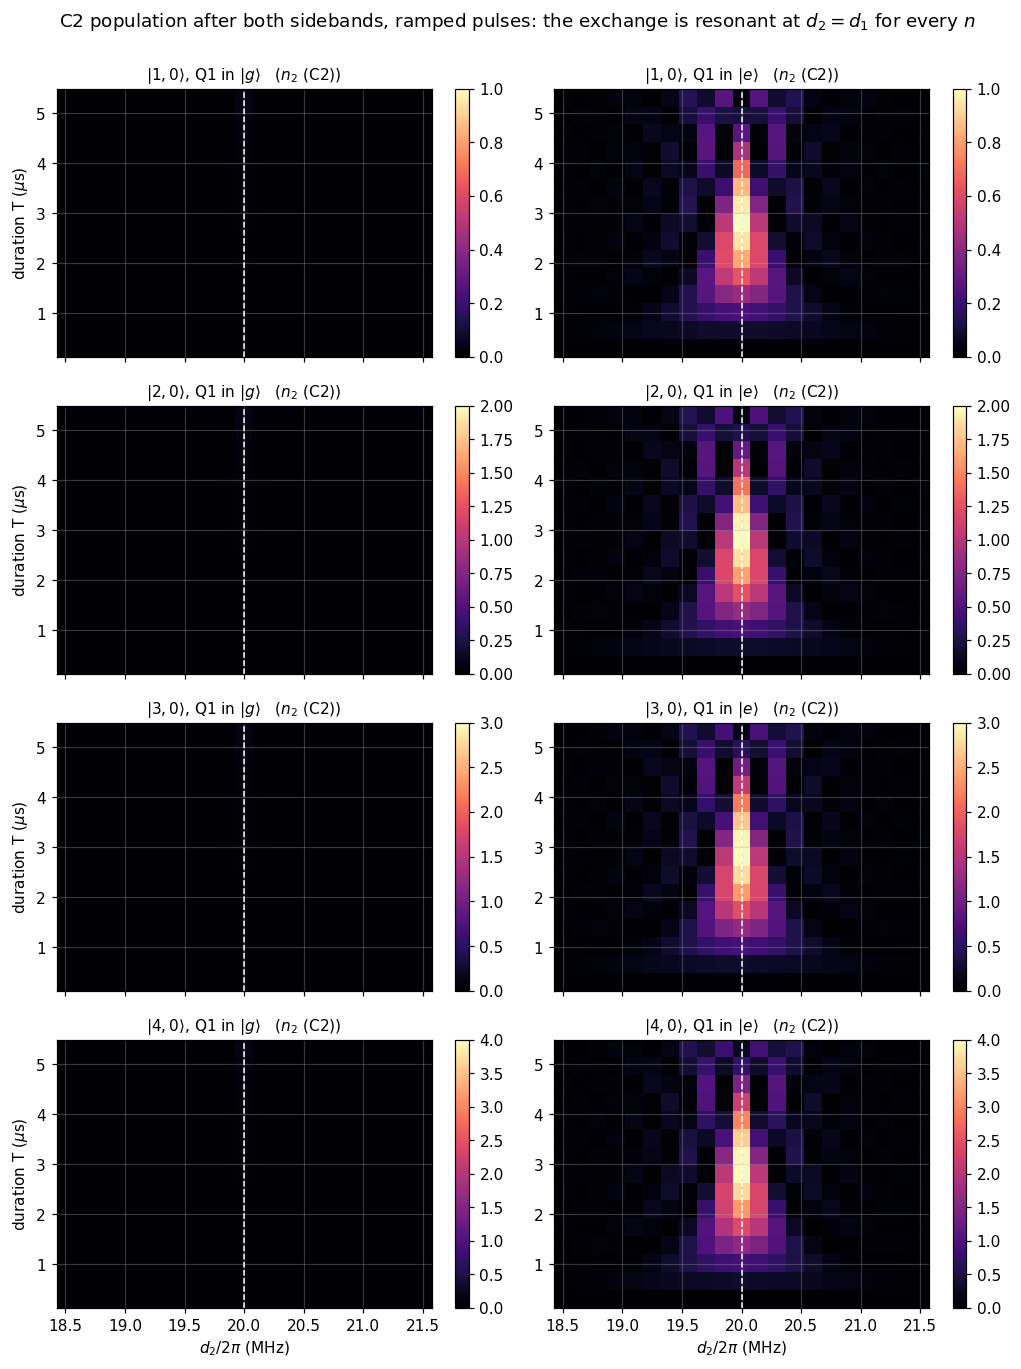

  n   d2 at peak (MHz)   peak n2 / n  |g> branch peak
  1              20.00        0.9995           0.0357
  2              20.00        0.9979           0.0357
  3              20.00        0.9957           0.0357
  4              20.00        0.9930           0.0357


In [ ]:
fig = plot_chevron_grid(runs1, P1["d1"] / MHz, obs=1,
                        suptitle="C2 population after both sidebands, ramped pulses: "
                                 "the exchange is resonant at $d_2=d_1$ for every $n$")
plt.show()

print(f"{'n':>3} {'d2 at peak (MHz)':>18} {'peak n2 / n':>13} {'|g> branch peak':>16}")
for n, T, d2, dat in runs1:
    j = int(np.argmax(dat[1, 1].max(axis=0)))
    print(f"{n:3d} {d2[j]:18.2f} {dat[1,1].max()/n:13.4f} {dat[0,1].max()/n:16.4f}")

The resonance does not move with $n$: the neck of every chevron sits on $d_2=d_1$, which
is the "no $\chi$, so every rung is degenerate" assumption behaving. The exchange
*rate* does grow with $n$ (the fringes tighten) because the sideband matrix element goes
as $\sqrt{n}$, so the swap time is $n$-dependent even though the resonance condition is
not — that is the thing the gate calibration has to live with, and it is why the fidelity
in task 2 is scored against photon number.

# Task 2 — the conditional beamsplitter gate

Calibrate once (duration, then the virtual Z), then score. **Rules for the fidelity**, as
specified:

* free corrections are a virtual Z on the transmon and one global virtual Z on each
  cavity separately: $W=\exp[-i(\mu_1n_1+\mu_2n_2+\mu_qn_q)]$;
* **no two-mode Z** — an $n_1n_2$ phase is not virtual and is not allowed;
* the triple $(\mu_1,\mu_2,\mu_q)$ is found once and then held **fixed for every random
  state**;
* random states are Haar-random over the whole C1 $\otimes$ C2 $\otimes$ Q1 scored
  subspace (Q1 in $\{g,e\}$, cavities with $n_1+n_2\le n_\mathrm{max}$), so they are
  genuinely entangled cavity–qubit–cavity states, not dual-rail;
* population that leaves the scored subspace is reported separately as leakage.

In [ ]:
# ============================== TASK 2 PARAMETERS ==============================
P2 = par(Nc=9, Nq=4,
         alpha=-150 * MHz,
         park="ef",
         g1=1.0 * MHz, g2=1.0 * MHz,
         d1=30 * MHz, d2=30 * MHz,
         sigma=0.075)                    # sigma * d ~ 4.5, comfortably adiabatic

THETA_CBS = np.pi / 2          # 50:50 conditional beamsplitter (pi = conditional swap)
NMAX_CAL = 4                   # photon range the calibration is optimised for
NMAX_LIST = [1, 2, 3, 4, 5, 6]    # photon ranges to score
N_RANDOM = 200                 # random states per point
# ==============================================================================

print("calibrating:")
T2, MU2, F2, dg2 = calibrate(P2, THETA_CBS, nmax=NMAX_CAL)
print(f"\nconditional BS rate dJ/2pi = {dJ_closed(P2)/MHz:+.4f} MHz")
print(f"pulse area equivalent square duration = {ramp_area(T2, P2['sigma'], 2):.4f} us")

calibrating:
  theta_cbs = 0.500 pi,  scored on n1+n2 <= 4 (D = 30)
  T = 2.6258 us   (closed form 2.5854),  g*T = 16.50
  virtual Z (mu1, mu2, muq)/pi = [-0.572 -0.572 -0.   ]
  process fidelity 1 - F = 3.309e-04

conditional BS rate dJ/2pi = -0.0556 MHz
pulse area equivalent square duration = 2.2904 us


In [ ]:
# score the SAME calibrated gate over a range of photon numbers
rows2 = []
for n in NMAX_LIST:
    idx = subspace(P2, n)
    A = gate_columns(P2, T2, idx)
    B = ideal_columns(P2, dg2["theta"], idx)
    F = process_fidelity(P2, A, B, MU2)                       # fixed VZ from above
    rand = random_state_fidelity(P2, A, B, MU2, idx, N_RANDOM)
    rows2.append(dict(nmax=n, D=len(idx), F=F, rand=rand))
    print(f"  n1+n2 <= {n}  (D = {len(idx):3d}):  1-F = {1-F:.3e}   "
          f"1-<F_rand> = {1-rand['mean']:.3e}   worst {1-rand['min']:.3e}   "
          f"leakage {rand['mean_leakage']:.3e}")
print(f"\nvirtual Z used everywhere: (mu1, mu2, muq)/pi = "
      f"{np.round(np.array(MU2)/np.pi, 4)}")

  n1+n2 <= 1  (D =   6):  1-F = 1.344e-04   1-<F_rand> = 2.823e-05   worst 4.364e-05   leakage 1.022e-04
  n1+n2 <= 2  (D =  12):  1-F = 1.403e-04   1-<F_rand> = 3.490e-05   worst 4.888e-05   leakage 1.081e-04
  n1+n2 <= 3  (D =  20):  1-F = 1.997e-04   1-<F_rand> = 3.712e-05   worst 5.686e-05   leakage 1.653e-04
  n1+n2 <= 4  (D =  30):  1-F = 3.309e-04   1-<F_rand> = 7.856e-05   worst 1.753e-04   leakage 2.472e-04
  n1+n2 <= 5  (D =  42):  1-F = 5.256e-04   1-<F_rand> = 2.334e-04   worst 5.178e-04   leakage 2.781e-04
  n1+n2 <= 6  (D =  56):  1-F = 9.670e-04   1-<F_rand> = 5.980e-04   worst 1.135e-03   leakage 3.315e-04

virtual Z used everywhere: (mu1, mu2, muq)/pi = [-0.572 -0.572 -0.   ]


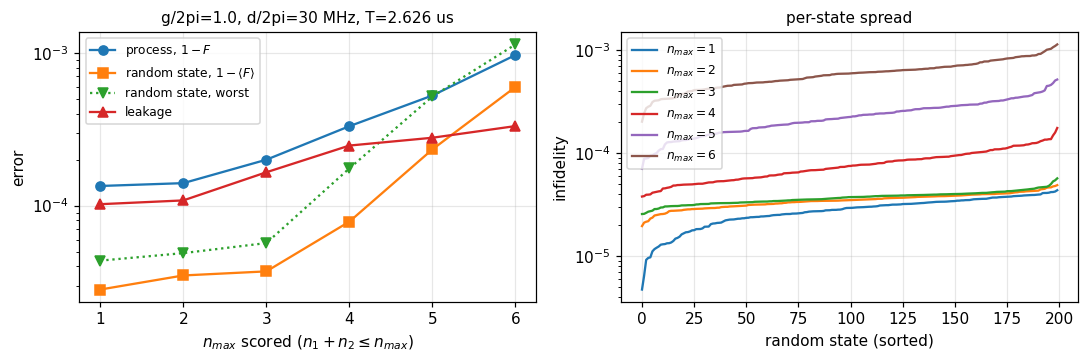

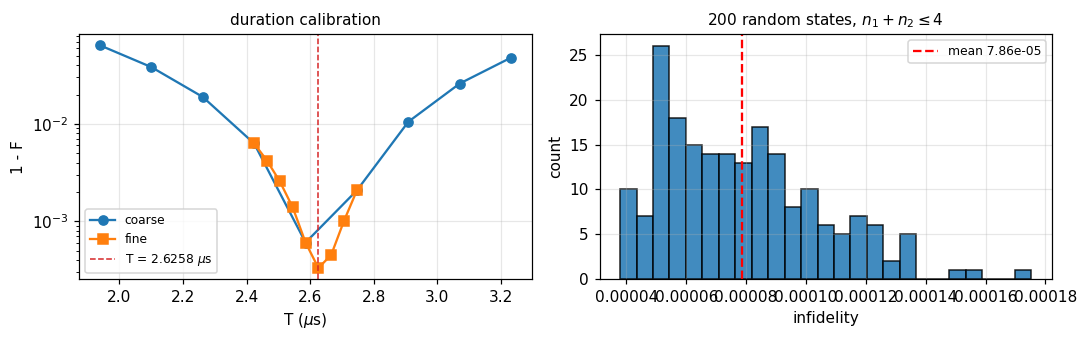

In [ ]:
fig = plot_fidelity_vs_photons(NMAX_LIST, rows2,
                               title=f"g/2pi={P2['g1']/MHz:.1f}, d/2pi={P2['d1']/MHz:.0f} MHz, "
                                     f"T={T2:.3f} us")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(dg2["Ts"], 1 - dg2["Fs"], "o-", label="coarse")
ax[0].plot(dg2["Ts_fine"], 1 - dg2["Fs_fine"], "s-", label="fine")
ax[0].axvline(T2, color="C3", ls="--", lw=1, label=f"T = {T2:.4f} $\\mu$s")
ax[0].set_yscale("log"); ax[0].set_xlabel("T ($\\mu$s)"); ax[0].set_ylabel("1 - F")
ax[0].set_title("duration calibration"); ax[0].legend()
inf = 1 - rows2[NMAX_LIST.index(NMAX_CAL)]["rand"]["fidelities"]
ax[1].hist(inf, bins=25, color="C0", edgecolor="k", alpha=0.85)
ax[1].axvline(inf.mean(), color="r", ls="--", label=f"mean {inf.mean():.2e}")
ax[1].set_xlabel("infidelity"); ax[1].set_ylabel("count")
ax[1].set_title(f"{N_RANDOM} random states, $n_1+n_2\\leq{NMAX_CAL}$"); ax[1].legend()
plt.tight_layout(); plt.show()

### Convince yourself: give it a state and look at the output

Below, edit `PSI_IN` to any cavity–qubit–cavity state. The cell runs the real pulse,
applies the **same** fixed virtual Z, and puts it next to the ideal conditional
beamsplitter acting on the same input. Box size is $|$amplitude$|$, colour is the phase,
so the two Hinton panels should be indistinguishable.

state fidelity |<ideal|out>|^2 = 0.99941024
residual global phase          = +0.9764 pi
norm out = 1.00000000   (any deficit is leakage to |f> or high Fock)


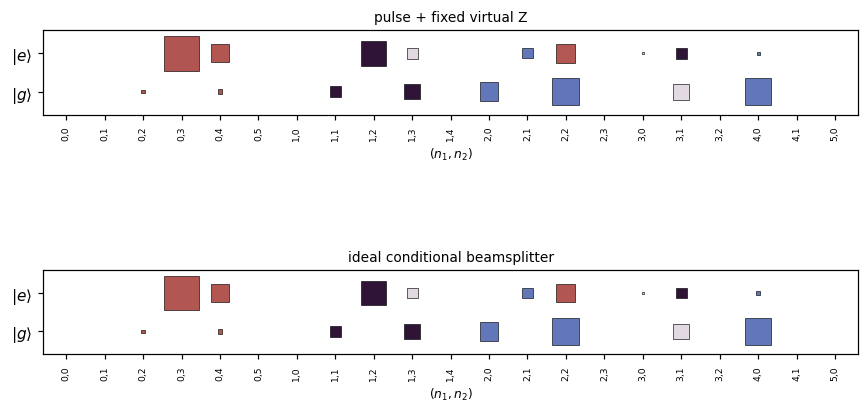

In [ ]:
# ============================== TASK 2: YOUR STATE ============================
o2 = ops_for(P2)
NMAX_SHOW = 5

# an entangled cavity-qubit-cavity state: edit freely
PSI_IN = (ket(o2, 3, 1, 0) + 1j * ket(o2, 0, 3, 1)
          + 0.7 * ket(o2, 1, 3, 1) - 0.5j * ket(o2, 2, 0, 0)).unit()
# ==============================================================================

psi_out = vz(P2, MU2) * run_gate(PSI_IN, P2, T2)
psi_ideal = ideal_cbs(P2, dg2["theta"]) * PSI_IN
overlap = complex(psi_ideal.overlap(psi_out))

print(f"state fidelity |<ideal|out>|^2 = {abs(overlap)**2:.8f}")
print(f"residual global phase          = {np.angle(overlap)/np.pi:+.4f} pi")
print(f"norm out = {psi_out.norm():.8f}   (any deficit is leakage to |f> or high Fock)")

fig, ax = plt.subplots(2, 1, figsize=(8, 5.0))
mx = max(np.abs(psi_out.full()).max(), np.abs(psi_ideal.full()).max())
hinton_state(psi_out * np.exp(-1j * np.angle(overlap)), P2, NMAX_SHOW, ax[0],
             "pulse + fixed virtual Z", max_amp=mx)
hinton_state(psi_ideal, P2, NMAX_SHOW, ax[1], "ideal conditional beamsplitter",
             max_amp=mx)
plt.tight_layout(); plt.show()

# Task 3 — the dynamical $\chi$, and the two-tone echo

On each transmon level the second order is

$$H^{(2)}_k=\chi^{(k)}_1n_1+\chi^{(k)}_2n_2+J^{(k)}\left(e^{-i\Delta\phi}a_2^\dagger a_1+\mathrm{h.c.}\right)$$

with, for **ef** parking, $\chi^{(g)}=\frac{g^2}{\alpha-d}$ and
$\chi^{(e)}=-\frac{2g^2}{d}+\frac{g^2}{d-\alpha}$, and for **ge** parking
$\chi^{(g)}=-\frac{g^2}{d}$ and $\chi^{(e)}=-\frac{2g^2}{d+\alpha}+\frac{g^2}{d}$. So

$$\delta\chi_\mathrm{ef}=\frac{2g^2\alpha}{d(d-\alpha)},\qquad \delta\chi_\mathrm{ge}=\frac{2g^2\alpha}{d(d+\alpha)}$$

### The obstruction, first

A single intermediate mode makes $H^{(2)}\propto B^\dagger B$ with
$B=g_1a_1+g_2e^{-i\Delta\phi}a_2$ — a **rank-one** form, so $\chi_1\chi_2=|J|^2$ and in
particular $\delta J=\delta\chi$ *identically*. For the sequence
[half A, $T_A$] — $\pi$ — [half B, $T_B$]:

$$\text{conditional }N\text{ phase}\propto T_A\delta\chi_A-T_B\delta\chi_B,\qquad \text{conditional BS}\propto T_A\delta J_A-s\,T_B\delta J_B$$

with $s=-1$ if the relative pump phase flips in half B. Nulling the first forces
$T_A\delta\chi_A=T_B\delta\chi_B$, which with $s=+1$ kills the beamsplitter too. **So the
phase flip is not optional** — no choice of detunings or drive strengths substitutes for
it, and neither does weakening the drive: the conditional $N$ phase is locked at exactly
half the BS angle whatever $g$ and $d$ are.

### Where the sign of the detuning comes in

$T_A,T_B>0$ with $T_A\delta\chi_A=T_B\delta\chi_B$ needs $\delta\chi_A$ and
$\delta\chi_B$ to have the **same sign**. From the formulae, ef parking has
$\delta\chi<0$ for $d>0$ and $>0$ for $d<0$, while ge parking is the other way round —
so a two-tone echo has to use **opposite-sign detunings** in its two halves. That is
exactly the "positive or negative can matter" point. With $|d_A|=|d_B|$ and equal $g$ the
two rates are equal, so $T_A=T_B$, and the effective rate is the harmonic mean of the two
$\delta\chi$: maximal when they match, and then identical to the single-tone echo. The
two-tone version is therefore a valid *alternative*, not a speed-up.

The cell below checks all of this by measuring $(A_e-A_g,\ B_e-B_g)$ directly.

In [ ]:
# ============================== TASK 3 PARAMETERS ==============================
G3 = 1.0 * MHz                   # sideband rate used by every variant
D3 = 30 * MHz                  # |detuning| used by every variant
ALPHA3 = -150 * MHz
NC3, NQ3 = 9, 4
SIGMA3 = 0.075
# ==============================================================================

base3 = dict(Nc=NC3, Nq=NQ3, alpha=ALPHA3, g1=G3, g2=G3, sigma=SIGMA3)
dchi_ef = lambda d: 2 * G3 ** 2 * ALPHA3 / (d * (d - ALPHA3))
dchi_ge = lambda d: 2 * G3 ** 2 * ALPHA3 / (d * (d + ALPHA3))

print("analytic dchi = chi_e - chi_g,  /2pi in MHz")
print(f"{'d/2pi':>8} {'ef parking':>12} {'ge parking':>12}")
for dm in (-60, -45, -30, -20, 20, 30, 45, 60):
    print(f"{dm:8.0f} {dchi_ef(dm*MHz)/MHz:12.4f} {dchi_ge(dm*MHz)/MHz:12.4f}")

a_ef, a_ge = dchi_ef(-D3), dchi_ge(+D3)
print(f"\npairing ef @ {-D3/MHz:+.0f} MHz with ge @ {+D3/MHz:+.0f} MHz:")
print(f"  dchi_A = {a_ef/MHz:+.4f},  dchi_B = {a_ge/MHz:+.4f} MHz  -> same sign, "
      f"T_A = T_B")
# the conditional BS angle is 2*(B_e - B_g) = T*(dchi_A + dchi_B), so for pi/2:
T3 = (np.pi / 2) / abs(a_ef + a_ge)
T3 = T3 + 2 * 2 * (2 * SIGMA3 - SIGMA3 * np.sqrt(np.pi) / 2 * erf(2.0))
print(f"  total duration for a conditional BS angle pi/2: T = {T3:.4f} us")

analytic dchi = chi_e - chi_g,  /2pi in MHz
   d/2pi   ef parking   ge parking
     -60       0.0556      -0.0238
     -45       0.0635      -0.0342
     -30       0.0833      -0.0556
     -20       0.1154      -0.0882
      20      -0.0882       0.1154
      30      -0.0556       0.0833
      45      -0.0342       0.0635
      60      -0.0238       0.0556

pairing ef @ -30 MHz with ge @ +30 MHz:
  dchi_A = +0.0833,  dchi_B = +0.0833 MHz  -> same sign, T_A = T_B
  total duration for a conditional BS angle pi/2: T = 1.8354 us


In [ ]:
# --- the four variants, as functions of the duration -----------------------------
pA = par(**base3, park="ef", d1=-D3, d2=-D3)      # two-tone echo, half A (near e1f0)
pB = par(**base3, park="ge", d1=+D3, d2=+D3)      # two-tone echo, half B (near g1e0)
X3 = pi_pulse(pA)


def seq_no_echo(T, **kw):
    "one section, no pi pulse: the bare dispersive gate"
    return section(pA, T)


def seq_single(T, flip=True, **kw):
    "ef parking in both halves; the relative pump phase flips in the second"
    return (section(pA, T / 2) + [("U", X3)]
            + section(pA, T / 2, phi2_offset=np.pi if flip else 0.0) + [("U", X3)])


def seq_two_tone(T, flip=True, phi_junction=0.0):
    '''
    ef parking near e1f0 for the first half, ge parking near g1e0 for the second, a ge
    pi pulse between and another to close.  phi_junction is a COMMON phase on both of
    half B's pumps: the halves run at different pump frequencies, so their rotating
    frames drift apart, and the pump phase at the junction is a real knob.
    '''
    return (section(pA, T / 2) + [("U", X3)]
            + section(pB, T / 2, phi2_offset=np.pi if flip else 0.0,
                      phi_common=phi_junction) + [("U", X3)])


# --- the junction phase is not free: scan it -------------------------------------
phis = np.linspace(0, 2 * np.pi, 25)
scan3 = np.array([conditional_angles(pA, seq_two_tone(T3, phi_junction=f))
                  for f in phis])
PHI_J = float(phis[int(np.argmin(np.abs(scan3[:, 0])))])
print(f"best junction phase: phi_J = {PHI_J/np.pi:.4f} pi")
print(f"spread of the conditional N phase over the whole scan: "
      f"{np.ptp(np.abs(scan3[:, 0]))/np.pi:.2e} pi")
print(f"spread of the conditional BS angle over the whole scan: "
      f"{np.ptp(np.abs(2*scan3[:, 1]))/np.pi:.2e} pi")
print()
print("Flat.  Changing the pump frequency between halves does make the two rotating")
print("frames drift apart, but the resulting phase is COMMON to both pumps, which is")
print("just a transmon frame rotation: it leaves |g|^2 and the relative phase alone, so")
print("it touches neither chi nor J.  At second order the effective Hamiltonian is")
print("transmon-diagonal, so that rotation is an ordinary virtual Z and stays")
print("unconditional.  The junction phase is therefore NOT a knob you have to chase.")

best junction phase: phi_J = 1.9167 pi
spread of the conditional N phase over the whole scan: 9.64e-08 pi
spread of the conditional BS angle over the whole scan: 1.93e-07 pi

Flat.  Changing the pump frequency between halves does make the two rotating
frames drift apart, but the resulting phase is COMMON to both pumps, which is
just a transmon frame rotation: it leaves |g|^2 and the relative phase alone, so
it touches neither chi nor J.  At second order the effective Hamiltonian is
transmon-diagonal, so that rotation is an ordinary virtual Z and stays
unconditional.  The junction phase is therefore NOT a knob you have to chase.


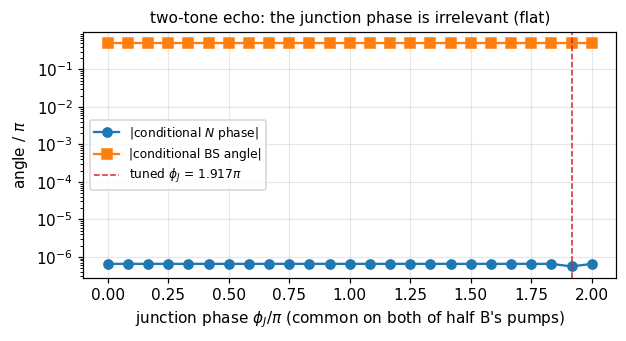

In [ ]:
fig, ax = plt.subplots(figsize=(5.8, 3.2))
ax.plot(phis / np.pi, np.abs(scan3[:, 0]) / np.pi, "o-", label="|conditional $N$ phase|")
ax.plot(phis / np.pi, np.abs(2 * scan3[:, 1]) / np.pi, "s-",
        label="|conditional BS angle|")
ax.axvline(PHI_J / np.pi, color="C3", ls="--", lw=1,
           label=f"tuned $\\phi_J$ = {PHI_J/np.pi:.3f}$\\pi$")
ax.set_xlabel("junction phase $\\phi_J/\\pi$ (common on both of half B's pumps)")
ax.set_ylabel("angle / $\\pi$"); ax.set_yscale("log"); ax.legend()
ax.set_title("two-tone echo: the junction phase is irrelevant (flat)")
plt.tight_layout(); plt.show()

In [ ]:
# --- compare every variant at the same duration ----------------------------------
variants = {
    "no echo (ef only)":                seq_no_echo(T3),
    "single-tone echo, phase flip":     seq_single(T3, flip=True),
    "single-tone echo, NO flip":        seq_single(T3, flip=False),
    "two-tone echo, NO flip":           seq_two_tone(T3, flip=False, phi_junction=PHI_J),
    "two-tone echo, flip, phi_J = 0":   seq_two_tone(T3, flip=True, phi_junction=0.0),
    "two-tone echo, flip, phi_J tuned": seq_two_tone(T3, flip=True, phi_junction=PHI_J),
}

print(f"{'variant':>36} {'cond. N phase':>16} {'cond. BS angle':>16}")
res3 = {}
for name, steps in variants.items():
    dA, dB = conditional_angles(pA, steps)
    res3[name] = (dA, 2 * dB)
    print(f"{name:>36} {dA/np.pi:15.5f}pi {2*dB/np.pi:15.5f}pi")
print()
print("BS angle is quoted as 2*(B_e - B_g), i.e. in the")
print("BS(theta) = exp(-i theta/2 (a1+ a2 + h.c.)) convention; the target is 0.5 pi.")
print("Without an echo the conditional N phase equals HALF the BS angle exactly,")
print("which is the rank-one lock: it cannot be tuned away by g or d.")

                             variant    cond. N phase   cond. BS angle
                   no echo (ef only)         0.27673pi         0.55345pi
        single-tone echo, phase flip         0.00000pi         0.49802pi
           single-tone echo, NO flip         0.00000pi        -0.00000pi
              two-tone echo, NO flip         0.00000pi        -0.00000pi
      two-tone echo, flip, phi_J = 0         0.00000pi         0.49801pi
    two-tone echo, flip, phi_J tuned         0.00000pi         0.49802pi

BS angle is quoted as 2*(B_e - B_g), i.e. in the
BS(theta) = exp(-i theta/2 (a1+ a2 + h.c.)) convention; the target is 0.5 pi.
Without an echo the conditional N phase equals HALF the BS angle exactly,
which is the rank-one lock: it cannot be tuned away by g or d.


In [ ]:
# --- sweep the duration: structural cancellation, or a coincidence? --------------
Ts3 = np.linspace(8 * SIGMA3 + 0.02, 1.6 * T3, 13)
curves = {
    "no echo (ef only)": lambda T: seq_no_echo(T),
    "single-tone echo, phase flip": lambda T: seq_single(T, flip=True),
    "two-tone echo, flip, phi_J tuned": lambda T: seq_two_tone(T, flip=True,
                                                               phi_junction=PHI_J),
}
sweep3 = {k: np.array([conditional_angles(pA, f(float(T))) for T in Ts3])
          for k, f in curves.items()}
print("done")

done


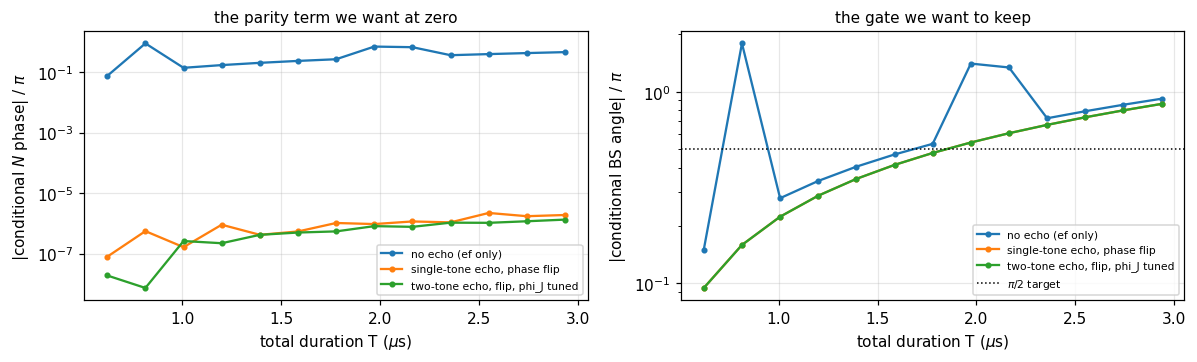

Both echoes hold the parity term at the solver floor across the whole range,
while the un-echoed gate sits at 0.1 - 1 pi.  The cancellation is structural.


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for name, c in sweep3.items():
    ax[0].plot(Ts3, np.abs(c[:, 0]) / np.pi, "o-", ms=3, label=name)
    ax[1].plot(Ts3, np.abs(2 * c[:, 1]) / np.pi, "o-", ms=3, label=name)
ax[0].set_ylabel("|conditional $N$ phase| / $\\pi$")
ax[0].set_title("the parity term we want at zero")
ax[1].set_ylabel("|conditional BS angle| / $\\pi$")
ax[1].axhline(0.5, color="k", ls=":", lw=1, label="$\\pi/2$ target")
ax[1].set_title("the gate we want to keep")
for a in ax:
    a.set_xlabel("total duration T ($\\mu$s)"); a.set_yscale("log"); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

print("Both echoes hold the parity term at the solver floor across the whole range,")
print("while the un-echoed gate sits at 0.1 - 1 pi.  The cancellation is structural.")

### Verdict on task 3

* **No echo.** The conditional $N$ phase is exactly half the conditional beamsplitter
  angle, at every duration and for every $g$ and $d$. This is the rank-one lock, so
  *reducing the drive or increasing the detuning does not help* — the ratio is fixed. If
  all your logical states share one total photon number the term collapses to a transmon
  virtual Z and you can ignore it; otherwise it is a real error, and that is precisely the
  large-photon-number case this notebook is about.
* **The phase flip is the active ingredient.** With the relative pump phase flipped in the
  second half, $J\to-J$ while $\chi\propto g_j^2$ stays put, so the halves add on the
  beamsplitter and cancel on the $\chi$. Without the flip both cancel and there is no gate
  — visible in the table as the two "NO flip" rows.
* **The two-tone echo works, with a caveat.** ef parking has $\delta\chi<0$ for $d>0$ and
  $>0$ for $d<0$, while ge parking is the other way round, so the two halves must use
  **opposite-sign detunings** to make $T_A\delta\chi_A = T_B\delta\chi_B$ solvable with
  positive durations. With $|d_A|=|d_B|$ and equal $g$ the rates match and $T_A=T_B$.
  The junction phase — the pump phase at the frequency change — turns out **not** to
  matter: the scan is flat. The frames do drift apart, but that phase is *common* to both
  pumps, so it is only a transmon frame rotation; it leaves $|g_j|^2$ and $\Delta\phi$
  alone and therefore touches neither $\chi$ nor $J$, and at second order the effective
  Hamiltonian is transmon-diagonal so the rotation stays an unconditional virtual Z.
* **Recommendation.** Use the single-tone echo. Same rate (the two-tone effective rate is
  the harmonic mean of the two $\delta\chi$, maximal when they are equal, and then equal
  to the single-tone value), one fewer frequency to generate, and no junction phase to
  chase.